IMPORTACIÓN Y CONFIGURACIÓN INICIAL DEL PROYECTO

# El objetivo es predecir el comportamiento para retener clientes. 
Puede analizar todos los datos relevantes de los clientes y desarrollar programas de retención de clientes específicos

## Contenido
Cada fila representa un cliente; cada columna contiene los atributos del cliente descritos en la columna Metadatos.

## El conjunto de datos incluye información sobre:

1. Clientes que se dieron de baja en el último mes: la columna se denomina "Abandono" (Churrn).
2. Servicios contratados por cada cliente: teléfono, líneas múltiples, internet, seguridad en línea, copia de seguridad en línea, protección de dispositivos, soporte técnico y streaming de TV y películas.
3. Información de la cuenta del cliente: antigüedad como cliente, contrato, método de pago, facturación electrónica, cargos mensuales y cargos totales.
4. Información demográfica sobre los clientes: género, rango de edad y si tienen pareja.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
import mlflow
import mlflow.sklearn
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

#Configuración de visualizaciones 
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns',None)
plt.rcParams['figure.figsize'] =(10,6)
warnings.filterwarnings('ignore')
# Semilla para reproducibilidad (clave en MLOps: todo debe ser reproducible)
RANDOM_STATE = 42


2.2 - Carga del dataset y primera inspección

In [89]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head(5)

Filas: 7043, Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Descripción de cada variable del dataset 

### Información demográfica del cliente 
 0   customerID: ID del cliente

 1   gender: Genero (M o F)

 2   SeniorCitizen: Indica si el usuario es de la tercera edad

 3   Partner: Si vive con su pareja   

 4   Dependents: Indica si el cliente tiene personas a cargo como niños o ancianos


### Relación con la empresa
 5   tenure: Es el número de meses que el cliente lleva usando los servicios de la compañia.

## Servicios contratados
 6   PhoneService: Indica si tiene contratado el servicio de telefonía

 7   MultipleLines: Indica si tiene contratado multiples líneas telefonicas

 8   InternetService: El tipo de conexión a internet del cliente 

 9   OnlineSecurity: Si tiene contratado un servicio extra de seguridad en línea

 10  OnlineBackup: Si tiene contratado un tipo de respaldo de datos en la nube 

 11  DeviceProtection: Tine un seguro o protección para sus equipos   

 12  TechSupport: Tien contratado soporte técnico

 13  StreamingTV: Utiliza el internet para ver tv por streaming

 14  StreamingMovies: Utiliza el internet para ver Movies por streaming  


## Información de la cuenta y pagos
 15  Contract: El tipo de contrato que tiene (MoM, One year, Two year)    

 16  PaperlessBilling: El cliente opto por la facturación electrónica en vez de la fisíca    

 17  PaymentMethod: Método de pago "Cheque, transferencia, tarjeta"   

 18  MonthlyCharges: Lo que el cliente paga mensualmente por el servicio
 
 19  TotalCharges: Total de dinero acumulado que el cliente ha pagado a la empresa en toda su historia   
 
## Variable Objetivo
 20  Churn: La variable objetivo que se busca predecir 

2.3 — Estadísticas descriptivas

In [91]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [92]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### ¿Qué significan las métricas que te arroja include='object'?
Como con el texto no se pueden hacer sumas ni promedios, Pandas  da un resumen estadístico basado en frecuencias y categorías:

1. count (Conteo): El número de filas que tienen datos en esa columna (excluyendo los valores nulos o vacíos).

2. unique (Únicos): Te dice cuántas categorías o opciones distintas existen en esa columna. Por ejemplo: En gender el valor de unique será 2 (Male y Female). En PaymentMethod será 4 (los cuatro métodos de pago que existen).

3. top (El líder): Es el valor que más veces se repite en esa columna (en estadística esto se conoce como la moda). Por ejemplo, si en Contract el valor top es Month-to-month, significa que la mayoría de los clientes prefiere el contrato mes a mes.

4. freq (Frecuencia): Es el número exacto de veces que aparece ese valor top. Si en gender el top es Male y la freq es 3555, significa que hay exactamente 3555 hombres en la base de datos.

2.4 — Valores nulos y duplicados

In [93]:
# Nulos explicitos
print("Valores nulos por columna: ")
print(df.isnull().sum())

#Duplicados
print(f"Valores duplicado: {df.duplicated().sum}")

Valores nulos por columna: 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Valores duplicado: <bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool>


revisamos que TotalCharges no tenga valores nulos disfrazados como string vacios 

In [94]:
print(df['TotalCharges'].apply(type).value_counts())
print((df['TotalCharges']=='').sum())

TotalCharges
<class 'str'>    7043
Name: count, dtype: int64
0


2.5 Análisis de la variable objetivos 

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


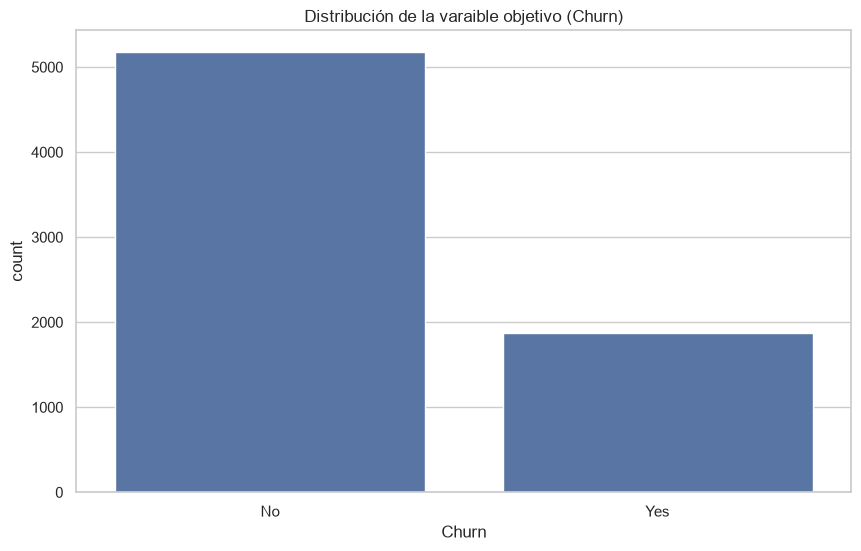

In [95]:
churn_count = df["Churn"].value_counts()
churn_pct =  df["Churn"].value_counts(normalize=True) * 100

print(churn_count)
print(churn_pct)

sns.countplot(data=df, x='Churn')
plt.title('Distribución de la varaible objetivo (Churn)')
plt.show()

Conclusión: las clases están desbalanceadas.

73% No, 27% Sí. Esto lo que hace es afectar directamente:

* Qué métrica usar despúes (accuracy es engañosa, necesitamos métricas como recall/F1/AUC-ROC)
* Si necesitamos técnicas de balanceo (SMOTE, class_weight) en el modelo.
* Como interpretamos el arbol de decisión.

**Lo anotamos ahora, lo resolvemos en el paso de modelado.**

2.6 - Análisis univariado: númericas vs categoricas

In [96]:
# Identificamos tipos de variables automáticamente

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Númercias:", num_cols)
print("Categóricas: ", cat_cols)

Númercias: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categóricas:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


En este análisis del punto 2.6, se puede observar que TotalCharges es una variable númericoa pero esta en la sección de categporica, esto esta potencialmente mal, porque  el modelo de Chi2 se usa para variables categoricas, entonces antes de ejecutar el modelo de Chi2 debemos ponerla en enla sección de num_cols haciendo un EDA

In [104]:
#Convertimos TotalCharges a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Veerificamos cuántos nulos quedaron tras la conversión
print(f"Nulos en TotalCharges tras conversión: {df['TotalCharges'].isnull().sum()}" )
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Nulos en TotalCharges tras conversión: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [109]:
#Recalculaos num_cols
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols) #Ahora si se debería incluir TotalCharges
#Volvemos a guardar las categoricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


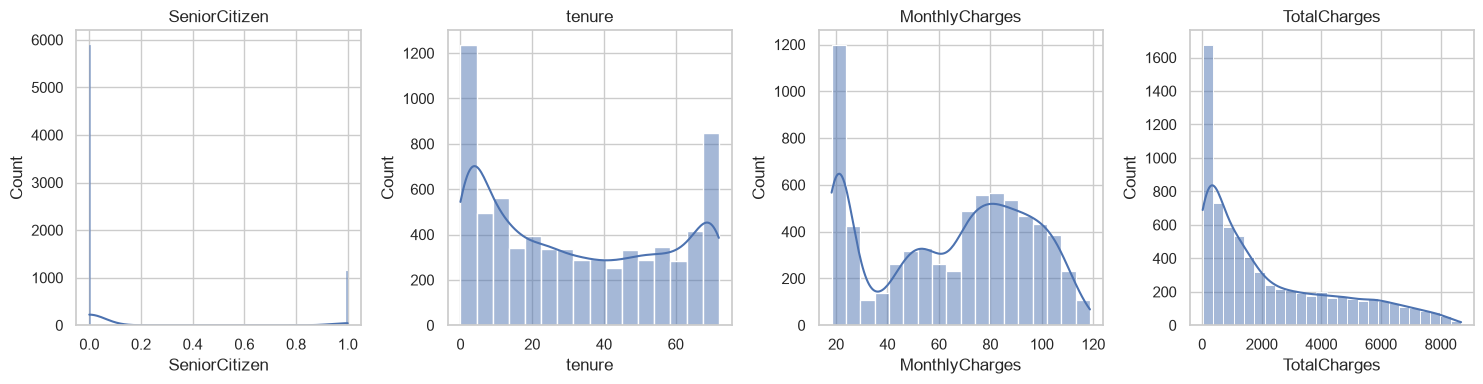

In [106]:
#Distribución de varaibles númericas
fig,axes = plt.subplots(1, len(num_cols), figsize=(15,4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Análisis Bivario
Este análisis nos permite cruzar las variables predictorias de una en una contra la variable objetivo

Entonces buscamos iterar sobre TODAS las categórias sin exepción.

In [110]:
#Primero excluimos la variable customerID & Churn (el identificador que no aporta nada y la variblae objetivo misma no tiene sentido comparar churn con churn)
cat_cols_analisis = [col for col in cat_cols if col not in ['customerID', 'Churn']]
print (f"Total de variables categóricas a analizar: {len(cat_cols_analisis)}")
print(cat_cols_analisis)

Total de variables categóricas a analizar: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Ahora grafocamos esas variables, en un grid dinámico que se ajuste a cuántas sean:

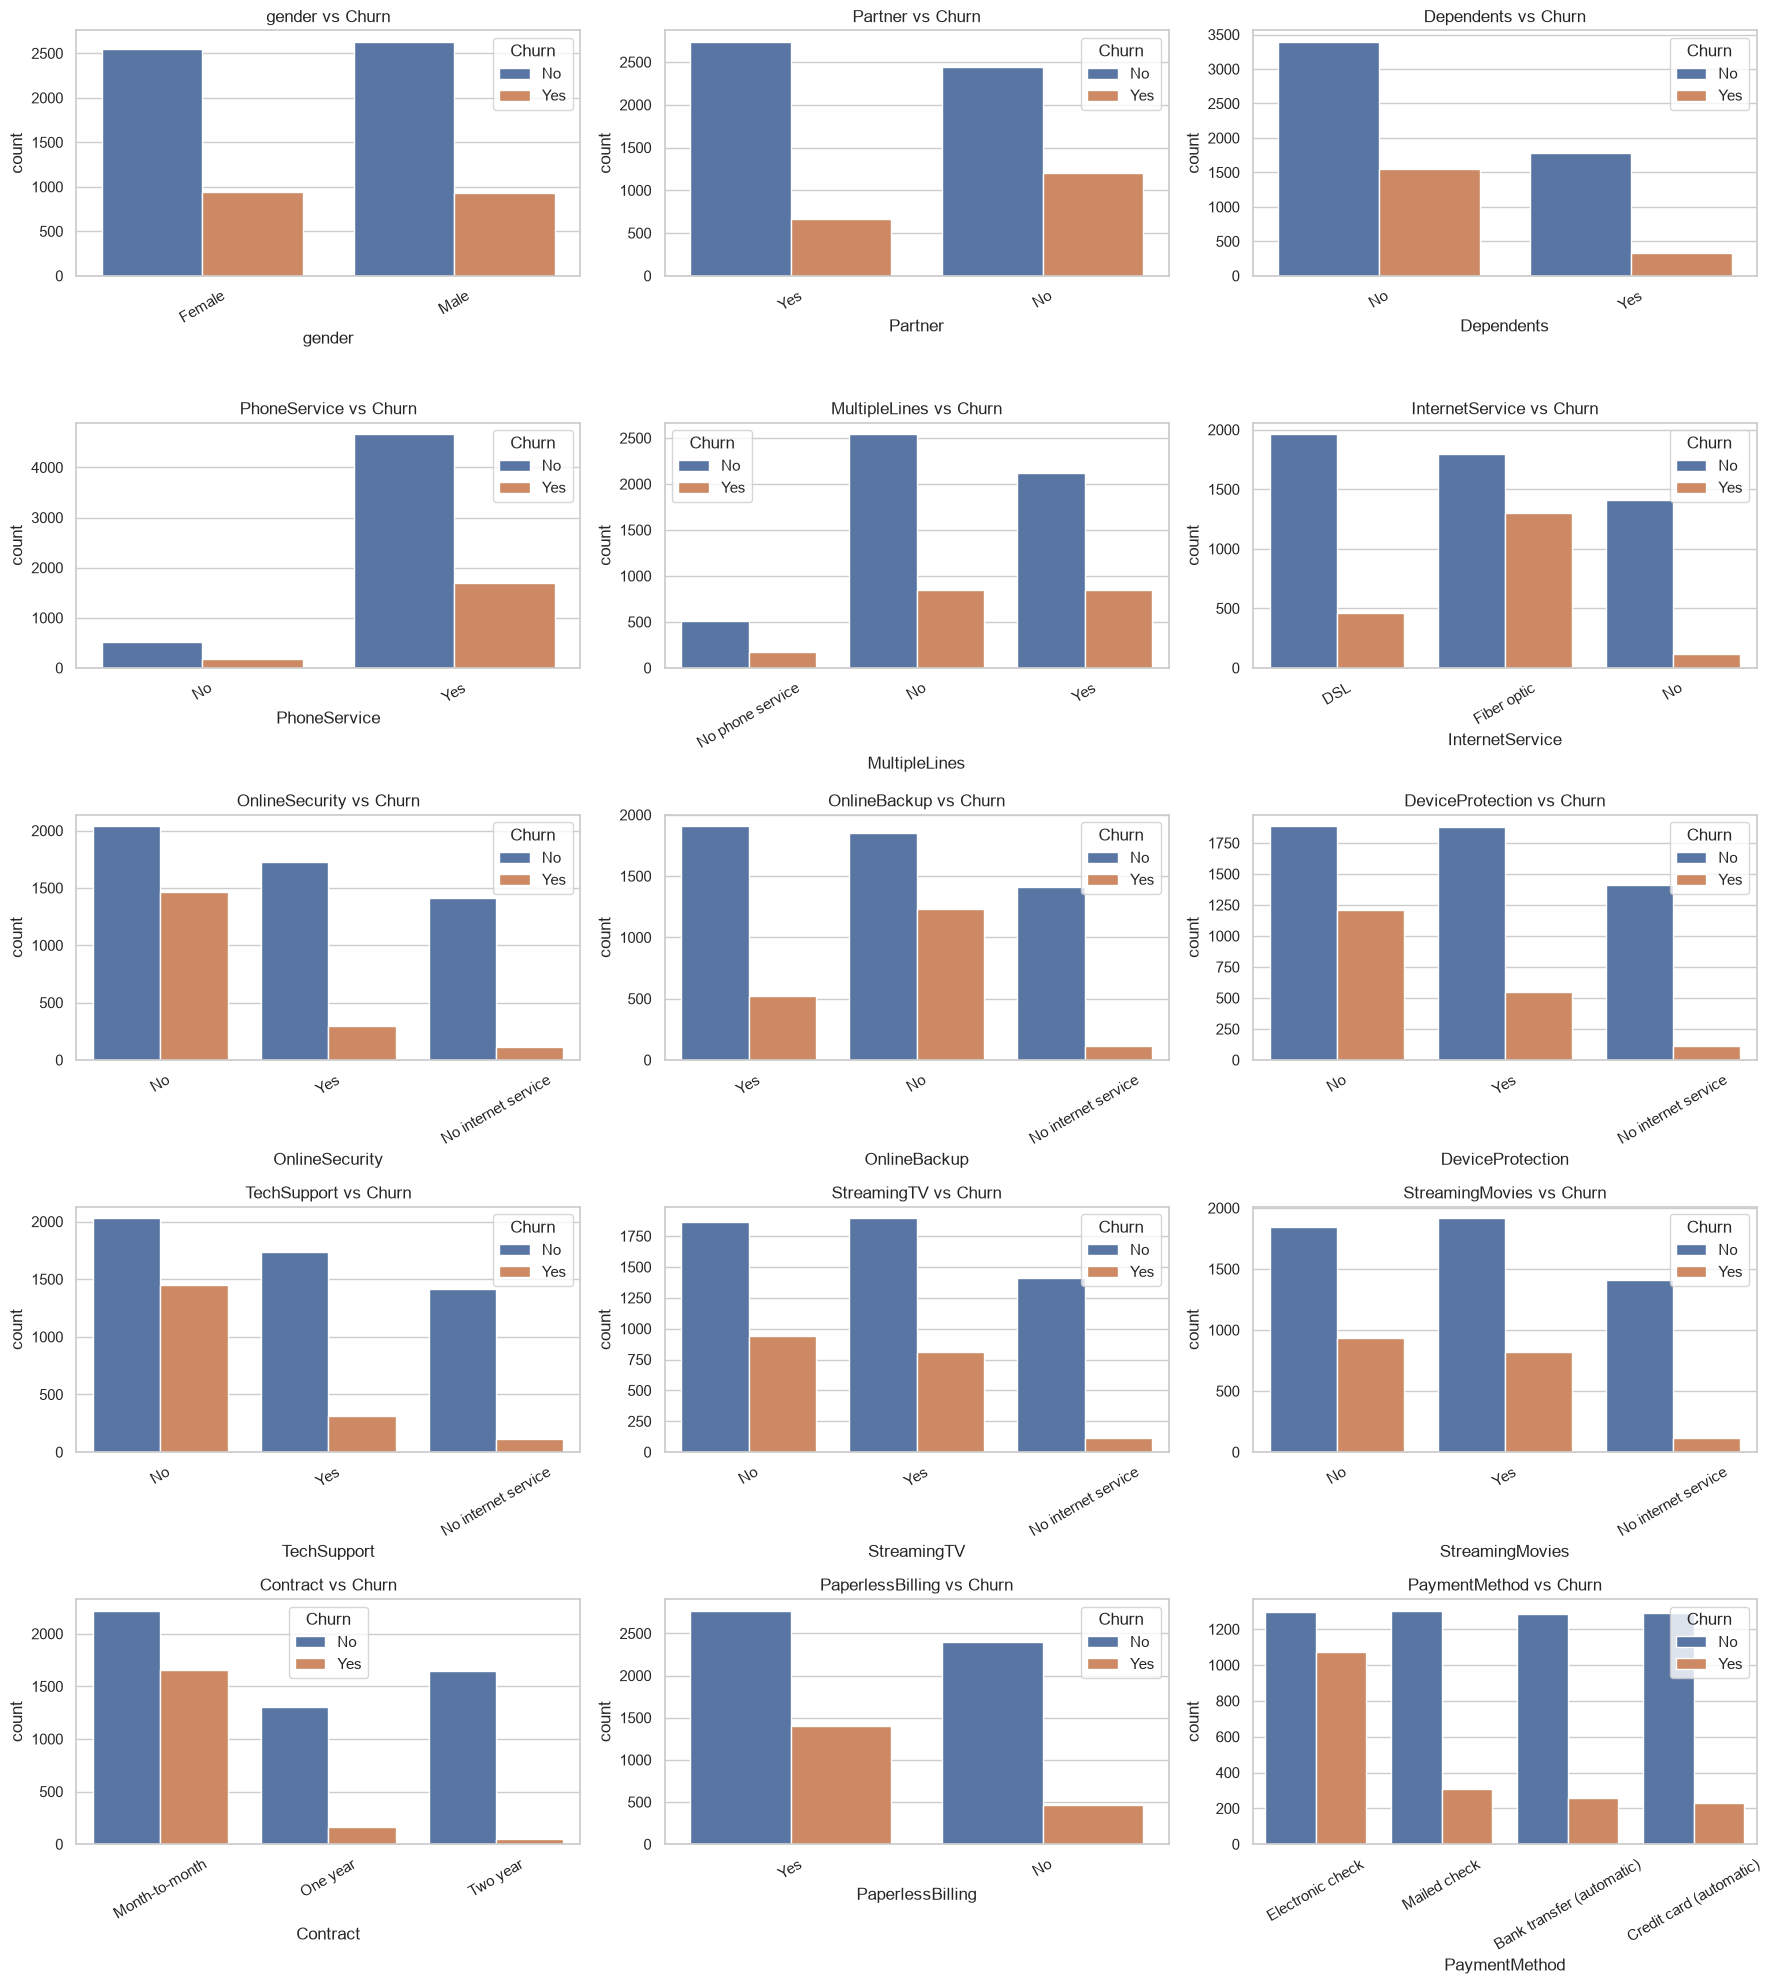

In [111]:
n_cols = 3
n_rows = math.ceil(len(cat_cols_analisis) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_analisis):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=30)

# Ocultar subplots vacíos si sobran
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Al mirar los gráficos, podemos analizar lo que es un detector de fugas, nos permite observar visualmente en qué servicios o perfiles específicos se está perdiendo más dinero y clientes

### Mirar gráficos no es suficiente para hacer conclusiones
No podemos quedarnos solo con la inspección visual, porqué es subjetiva. Debemos calcular una métrica de asociación real para cada categórica contra Churn, usando el estadistico
**Chi-cuadrado** ( Es el test estandar para merdir si dos varibales categorias están relacionada)

Nota: este método es solo para variables categoricas, para las númericas se debe usar otro método diferente

Cómo interpretar esto:

p_valor < 0.05 → hay evidencia estadística de que la variable sí está asociada con Churn (rechazamos la hipótesis de independencia)

In [112]:
resultados_chi2 = []

for col in cat_cols_analisis:
    tabla_contingencia = pd.crosstab(df[col], df['Churn'])
    chi2, p_valor,  dof, expected = chi2_contingency(tabla_contingencia)
    resultados_chi2.append({'variable': col, 'chi2': chi2, 'p_valor': p_valor})

df_chi2 = pd.DataFrame(resultados_chi2).sort_values('chi2', ascending=False)
df_chi2

,variable,chi2,p_valor
12,Contract,1184.596572,5.863038e-258
6,OnlineSecurity,849.998968,2.661150e-185
9,TechSupport,828.197068,1.443084e-180
5,InternetService,732.309590,9.571788e-160
14,PaymentMethod,648.142327,3.682355e-140
7,OnlineBackup,601.812790,2.079759e-131
8,DeviceProtection,558.419369,5.505219e-122
11,StreamingMovies,375.661479,2.667757e-82
10,StreamingTV,374.203943,5.528994e-82
13,PaperlessBilling,258.277649,4.073355e-58


**2.7 Análisis univariado solo númericos**

En esta parte hacemos el análisis de que varaibles númericas son las que mas influyen en los resultados


Como Churn es binaria y las numéricas son continuas, el equivalente al chi2 aquí es el test de Mann-Whitney U (más robusto que t-test porque no asume distribución normal)

In [115]:
resultados_num = []

for col in num_cols:
    grupo_no = df[df['Churn'] == 'No'][col].dropna()
    grupo_si = df[df['Churn'] == 'Yes'][col].dropna()
    stat, p_valor = mannwhitneyu(grupo_no, grupo_si)
    resultados_num.append({'variable': col, 'estadistico': stat, 'p_valor': p_valor})

df_num_test = pd.DataFrame(resultados_num).sort_values('p_valor')
df_num_test

,variable,estadistico,p_valor
1,tenure,7154668.0,2.419636e-208
3,TotalCharges,6288982.0,1.995985e-84
2,MonthlyCharges,3667080.5,3.311628e-54
0,SeniorCitizen,4226068.0,9.588357e-37


Interpretación de los resultados:

Ternure: Tiene una asociación brutalmente fuerte con Churn. Es, con muucha venta, la variable numérica más predictiva. 

TotalCharges: Fuerte también, aunque menos que ternure, lógico, porque TotalCharges está matemáticamente correlacionado con ternure ( a más tiempo, más gasto acumulado)

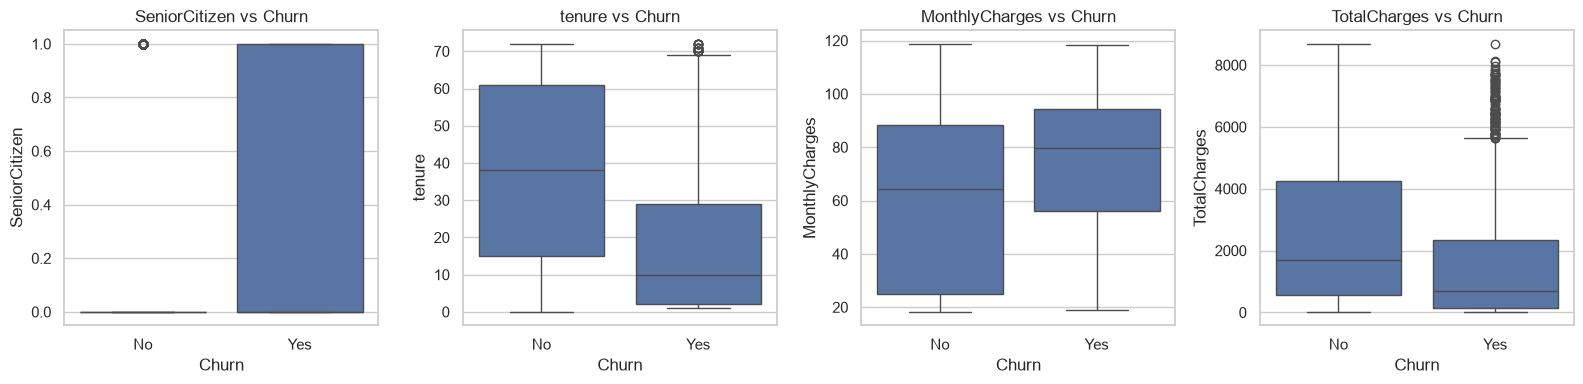

In [118]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(16,4))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

2.8 — Matriz de correlación (numéricas)

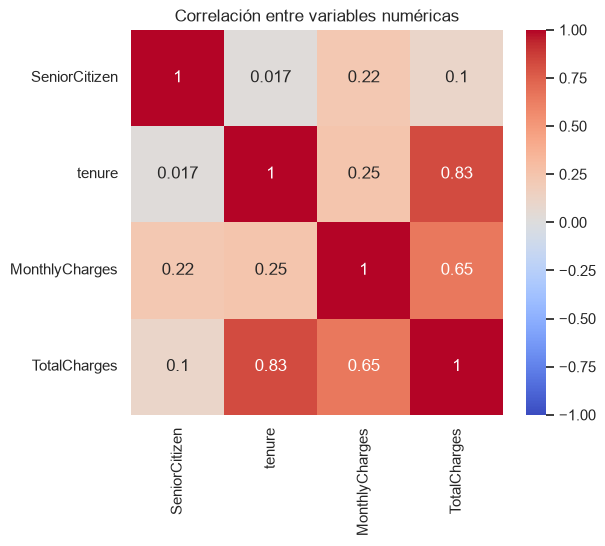

In [125]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas')
plt.show()

### Con esto, el EDA queda completo. Resumen de lo que sabemos hasta ahora:
✅ Estructura del dataset revisada (tipos, nulos explícitos y disfrazados)

✅ Variable objetivo desbalanceada (~73%/27%) → hay que tenerlo en cuenta en modelado

✅ customerID no aporta, se descarta

✅ TotalCharges tenía nulos disfrazados, corregidos, y coinciden con clientes de tenure=0

✅ Ranking objetivo de variables categóricas por Chi-cuadrado (Contract, OnlineSecurity, TechSupport arriba; gender, PhoneService abajo)

✅ Ranking objetivo de variables numéricas por Mann-Whitney (tenure, TotalCharges, MonthlyCharges fuertes; SeniorCitizen débil)

✅ Posible multicolinealidad entre tenure y TotalCharges, pendiente de confirmar

### Paso 3: Limpieza y tratamiento
Aquí es donde, con toda esta evidencia en mano (no antes), tomamos decisiones. Lo vamos a dividir en sub-pasos igual que hicimos con el EDA:


3.1 Tratamiento de nulos en TotalCharges

3.2 Decisión sobre variables poco predictivas (gender, PhoneService)

3.3 Detección y tratamiento de outliers

3.4 Eliminación de columnas no útiles (customerID)

3.5 Encoding de variables categóricas (para que el árbol las pueda usar)

3.6 Verificación final del dataset limpio

Solución punto 3: 

3.1 — Tratamiento de nulos en TotalCharges

In [120]:
df[df['tenure']==0] [['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [122]:
#Verificación previa: confirmamos que TODOS los nulos corresponden a tenure = 0
nulos_antes = df[df['TotalCharges'].isnull()]
print(f"Total de nulos: {len(nulos_antes)}")
print(f"¿Todos tienen tenure = 0?: {(nulos_antes['tenure'] == 0).all()}")

Total de nulos: 11
¿Todos tienen tenure = 0?: True


Este assert/verificación es clave: antes de aplicar la corrección, confirmamos que la premisa es 100% cierta, no solo "probablemente cierta". Si por alguna razón hubiera un nulo con tenure != 0, la regla de negocio no aplicaría para ese caso y tendría que investigarlo aparte.

In [123]:
#Aplicamops la correción
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verificación posterior
print(f"Nulos restantes en TotalCharges: {df['TotalCharges'].isnull().sum()}")


Nulos restantes en TotalCharges: 0



DECISIÓN DE LIMPIEZA - TotalCharges:

Los 11 valores nulos correspondían a clientes con tenure=0 (recién ingresados,
sin ciclo de facturación completado). Se imputaron con 0 porque representa
el valor real de facturación acumulada para ese estado del cliente, no una
estimación estadística.

In [124]:
correlacion_ternure_total = df[['tenure', 'TotalCharges']].corr().iloc[0,1]
print(f"Correlación ternure vs TotalCharges: {correlacion_ternure_total:.3f}")

Correlación ternure vs TotalCharges: 0.826


la idea de mirar esta alta correlación es mirar si 2 variables predictorias están midiendo en esencia lo mismo y el proposito es evitar reduncancia innecesario

 Paso 3.2

 no eliminamos ninguna variable por baja significancia todavía. Solo eliminamos lo que sabemos con certeza que no es una variable predictiva real:

In [126]:
df_clean = df.drop(columns=['customerID'])
print(df_clean.shape)

(7043, 20)


Paso 3.3 - Detección y tratamiento de Outliers

DECISIÓN - Outliers:
Se revisaron los boxplots de las variables numéricas (tenure, MonthlyCharges,
TotalCharges). No se encontraron outliers por error de captura. El único valor
alejado en TotalCharges corresponde a un cliente con alto consumo acumulado
legítimo. No se aplica tratamiento de outliers dado que:
1) Son valores reales de negocio, no errores.
2) El modelo elegido (Decision Tree) es robusto a valores extremos por diseño.

Paso 3.4 - Verificación de consistencia general antes de encoding
Antes de pasar al encoding (3.5), hagamos una última pasada de sanidad sobre todo el dataset limpio hasta ahora, para asegurarnos de que no se nos escapó nada:

In [128]:
#Verifiación de consistencia general
print("Shape final: ", df_clean.shape)
print("\n Nulos restantes por columna:")
print(df_clean.isnull().sum().sum(), "Nulos total")

print("\nTipo de datos:")
print(df_clean.dtypes.value_counts())


print("\nDuplicados:")
print(df_clean.duplicated().sum())

Shape final:  (7043, 20)

 Nulos restantes por columna:
0 Nulos total

Tipo de datos:
str        16
int64       2
float64     2
Name: count, dtype: int64

Duplicados:
22


Antes de pasar al 3.5, debemos analziar los datos, tenemos str y duplicados, así que le dedicamos un tiempo en analizar:

In [129]:
print(df_clean.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


Vamos a investigar los duplicados:

In [131]:
duplicados = df_clean[df_clean.duplicated(keep=False)]
print(f"Total de filas involucradas en duplicados: {len(duplicados)}")
duplicados.sort_values(by=list(df_clean.columns)).head(20)

Total de filas involucradas en duplicados: 42


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


In [133]:
# ¿Se concentran en clientes nuevos (tenure=0)?
print(duplicados['tenure'].value_counts())

# ¿Se concentran en un tipo de contrato o perfil específico?
print(duplicados['Contract'].value_counts())
print(duplicados['Churn'].value_counts())

tenure
1    42
Name: count, dtype: int64
Contract
Month-to-month    42
Name: count, dtype: int64
Churn
Yes    24
No     18
Name: count, dtype: int64


In [134]:
# Comparación de los dos métodos
print("Con duplicated().sum() [default: marca todas menos la primera aparición]:", 
      df_clean.duplicated().sum())

print("Con duplicated(keep=False) [marca TODAS las apariciones, incluida la primera]:", 
      df_clean.duplicated(keep=False).sum())

Con duplicated().sum() [default: marca todas menos la primera aparición]: 22
Con duplicated(keep=False) [marca TODAS las apariciones, incluida la primera]: 42


DECISIÓN - Duplicados:

Se identificaron 42 filas involucradas en duplicados (22 registros duplicados
respecto al total, considerando solo la primera ocurrencia como base). Se
decide NO eliminarlos porque:

1) Sin customerID, dos clientes distintos con el mismo perfil de servicios
   son indistinguibles pero legítimamente reales.
2) De esos duplicados, 24 corresponden a Churn='Yes' vs 18 a 'No' — eliminarlos
   reduciría aún más la ya escasa clase minoritaria (~27% del dataset),
   empeorando el desbalance de clases para el modelado.

3.5 - Encoding para variables caegoricas 

Vamos a usar "dummy variable trap"m con drop=firts porque aunque el arbol de decision no tiene problema con que esto se haga si mas adelante implementamos otros modelos pueden que esos otros sí, y tambien por eficiencia del modelo es mejor implementarlo 

Hay que usar One-Hot para los datos categoricos pero se recomienda usar Ordial Encoding para la columna de Contract ya que el tener Month, One year, Two year, tienen una relación entre estos tiempos

DECISIÓN - Encoding de variables categóricas:
1. Variables binarias (gender, Partner, Dependents, PhoneService, 
   PaperlessBilling, Churn): mapeo manual 0/1.
2. Contract: Ordinal Encoding (0=Month-to-month, 1=One year, 2=Two year), 
   porque existe una jerarquía real de duración/compromiso.
3. Resto de categóricas nominales sin orden (InternetService, PaymentMethod, 
   MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, 
   StreamingTV, StreamingMovies): One-Hot Encoding con drop_first=True, 
   porque no existe relación de orden entre sus categorías.

1. Tratamiento de las variables Binarias, para eso primero confirmamos esos valores únicos 

In [136]:
# Variables binarias: mapeo directo 0/1
binarias = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binarias:
    print(f"{col}: {df_clean[col].unique()}")

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Churn: <StringArray>
['No', 'Yes']
Length: 2, dtype: str


1.1 Armamos el diccionario de mapeo

In [137]:
mapeos_binarios = {
    'gender': {'Female': 0, 'Male':1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
    'Churn': {'No': 0, 'Yes': 1}
}

for col, mapeo in mapeos_binarios.items():
    df_clean[col] = df_clean[col].map(mapeo)

# Verificación
df_clean[list(mapeos_binarios.keys())].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


1.2 Ahora el Ordinal Encoding para Contract

In [138]:
mapeo_contract = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year':2
}
df_clean['Contract'] = df_clean['Contract'].map(mapeo_contract)
df_clean['Contract'].value_counts()

Contract
0    3875
2    1695
1    1473
Name: count, dtype: int64

1.3 One-Hot Encoding para el resto de nominales

primero identificados exactamente cuáles quedan pendiente (todas las categóricas menos las que ya tratamos)

In [140]:
categoricas_ya_tratadas = list(mapeos_binarios.keys()) + ['Contract']
categoricas_pendientes = [col for col in df_clean.select_dtypes(include='str').columns
                          if col not in categoricas_ya_tratadas]
print("Pendientes de One-Hot:", categoricas_pendientes)

Pendientes de One-Hot: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']


In [142]:
df_clean = pd.get_dummies(df_clean, columns=categoricas_pendientes, drop_first=True)

print(f"Shape antes: (7043,20)")
print(f"Shape después: {df_clean.shape}")
df_clean.head()

Shape antes: (7043,20)
Shape después: (7043, 30)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,1,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False
4,0,0,0,0,2,1,0,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


Una verificación crpitica que no podemos saltarnos es el tipo de datos resultantes:

In [143]:
df_clean.dtypes.value_counts()

bool       19
int64       9
float64     2
Name: count, dtype: int64

Ojo con esto: pd.get_dummies en pandas puede generar columnas de tipo bool (True/False) en vez de int (0/1), dependiendo de la versión. Aunque scikit-learn generalmente maneja bien los booleanos, es buena práctica forzarlos a enteros explícitamente para evitar sorpresas más adelante (por ejemplo, si luego usamos alguna librería de visualización de árboles o SHAP que espere números):

In [144]:
# Identificar columnas booleanas y convertirlas a int
cols_bool = df_clean.select_dtypes(include='bool').columns
df_clean[cols_bool] = df_clean[cols_bool].astype(int)

df_clean.dtypes.value_counts()

int64      28
float64     2
Name: count, dtype: int64

In [145]:
assert df_clean.select_dtypes(include='str').shape[1] == 0, "Aún quedan columnas de texto sin codificar"
print("✅ Dataset completamente numérico, listo para modelar")
print(f"Shape final: {df_clean.shape}")

✅ Dataset completamente numérico, listo para modelar
Shape final: (7043, 30)


In [146]:
print("""
RESUMEN DE LIMPIEZA Y PREPROCESAMIENTO - dataset Telco Churn
================================================================
1. customerID: eliminado (identificador, no predictivo)
2. TotalCharges: convertido a numérico; 11 nulos (tenure=0) imputados con 0
3. Outliers: revisados, son valores legítimos de negocio, no tratados
4. Duplicados: 42 filas involucradas, conservadas (evitar agravar 
   desbalance de clases, ya que 24/42 son Churn='Yes')
5. Encoding:
   - Binarias (gender, Partner, Dependents, PhoneService, 
     PaperlessBilling, Churn): mapeo manual 0/1
   - Contract: Ordinal Encoding (orden real de duración)
   - Resto de nominales: One-Hot Encoding con drop_first=True
6. Shape final: {shape}
================================================================
""".format(shape=df_clean.shape))


RESUMEN DE LIMPIEZA Y PREPROCESAMIENTO - dataset Telco Churn
1. customerID: eliminado (identificador, no predictivo)
2. TotalCharges: convertido a numérico; 11 nulos (tenure=0) imputados con 0
3. Outliers: revisados, son valores legítimos de negocio, no tratados
4. Duplicados: 42 filas involucradas, conservadas (evitar agravar 
   desbalance de clases, ya que 24/42 son Churn='Yes')
5. Encoding:
   - Binarias (gender, Partner, Dependents, PhoneService, 
     PaperlessBilling, Churn): mapeo manual 0/1
   - Contract: Ordinal Encoding (orden real de duración)
   - Resto de nominales: One-Hot Encoding con drop_first=True
6. Shape final: (7043, 30)



### Guardando el dataset procesado (primer gesto hacia MLOps)
Aunque todavía estamos en el notebook, ya podemos empezar a adoptar la disciplina de separar data/raw/ de data/processed/ — esto es literalmente la estructura que vamos a formalizar en la Fase 2:

In [16]:
df_clean.to_csv('../data/processed/telco_churn_clean.csv', index=False)
print("Dataset procesado guardado en data/processed/")

NameError: name 'df_clean' is not defined

Finalizado el paso 3, Damos inico al paso 4
# PASO 4: PREPARACIÓN PARA EL MODELADO.

In [5]:
df_clean = pd.read_csv('../data/processed/telco_churn_clean.csv')
print(f'Dataset creado con exito: {df_clean.shape}')

Dataset creado con exito: (7043, 30)


### 4.1 - Separar features (X) y Target (y)


In [6]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nDistribución de y:\n {y.value_counts(normalize=True)}")

Shape de X: (7043, 29)
Shape de y: (7043,)

Distribución de y:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


la sección de línea de value_counts, nos dice la proporción de clientes que se quedan y los que se van, podemos detectar que la clase se encuentra desbalanceada

Ya sabemos algo clave del EDA: Churn está desbalanceada (~73% No / ~27% Yes). Si hacemos un split aleatorio simple con train_test_split, existe el riesgo de que, por puro azar, el conjunto de entrenamiento o el de prueba terminen con una proporción de clases distinta a la real (por ejemplo, que el test set quede con 20% de Yes en vez de 27%).
scikit-learn tiene un parámetro llamado stratify que resuelve exactamente esto: fuerza a que la proporción de clases en train y test sea igual a la proporción original del dataset completo.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape[0]} Filas")
print(f"Test: {X_test.shape[0]} Filas")

print(f"\n Proporción de clases en y_train: {y_train.value_counts(normalize=True)}")
print(f"\n Proporción de clases en y_test: {y_test.value_counts(normalize=True)}")

Train: 5634 Filas
Test: 1409 Filas

 Proporción de clases en y_train: Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

 Proporción de clases en y_test: Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


#### Antes de entrenar: una decisión pendiente que dejamos abierta hace rato
¿Recuerdas que en el EDA identificamos el desbalance de clases y dijimos "lo resolvemos en modelado"? Este es el momento. Con stratify ya garantizamos que el split sea representativo, pero eso no resuelve el desbalance en sí — el árbol todavía va a entrenar viendo 73% de ejemplos "No" y solo 27% "Yes", lo que puede hacer que tienda a favorecer predecir "No" porque estadísticamente "acierta más" haciendo eso.

Hay varias estrategias para esto, cada una con trade-offs distintos:

1. No hacer nada todavía: entrenar el árbol baseline tal cual, medir qué tan mal/bien maneja el desbalance, y decidir después con evidencia si realmente es un problema.
2. class_weight='balanced': un parámetro del propio DecisionTreeClassifier que penaliza más los errores en la clase minoritaria, sin tocar los datos.
3.  SMOTE: técnica que genera ejemplos sintéticos de la clase minoritaria en el set de entrenamiento (nunca en el de test).
4. Undersampling: reducir la clase mayoritaria para igualar proporciones (generalmente no recomendado aquí porque perderías muchos datos).


Mi recomendación pedagógica: sigamos el mismo principio que hemos aplicado en todo el proyecto — entrenar primero un modelo baseline SIN ninguna corrección de desbalance, medir sus métricas (especialmente recall en la clase "Yes"), y con esa evidencia decidir si de verdad necesitamos class_weight o SMOTE, en vez de aplicarlo preventivamente sin saber si hace falta.

**Enfoque:** Baseline primero, y luego con la evidencia miramos si se debe corregir con class_weight o SMOTE 

## Paso 5: entrenamiento del árbol de decisión baseline.

In [9]:

#Modelo baseline: sin restricciones, sin balanceo, solo la semilla para reproducibilidad
modelo_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
modelo_baseline.fit(X_train, y_train)

print("✅Modelo entrenado")
print(f"Profundidad del árbol: {modelo_baseline.get_depth()}")
print(f"Número de hojas del árbol: {modelo_baseline.get_n_leaves()}")


✅Modelo entrenado
Profundidad del árbol: 24
Número de hojas del árbol: 1088


5.2 — Primera predicción (antes de evaluar formalmente)

In [10]:
y_pred_train = modelo_baseline.predict(X_train)
y_pred_test = modelo_baseline.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en TRAIN: {acc_train:.4f}")
print(f"Accuracy en TEST: {acc_test:.4f}")

Accuracy en TRAIN: 0.9980
Accuracy en TEST: 0.7367


Diagnóstico_ Overfitting (sobreajuste) severo

Un árbol con profundidad 24 y 1088 hojas prácticamente memorizó el conjunto de entrenamiento en vez de aprender patrones generales. Con tantas hojas, muchas terminan conteniendo 1 o 2 observaciones específicas — el árbol creó una "regla" ultra-específica para casi cada cliente individual del training set, en vez de encontrar reglas que generalicen a clientes nuevos.

Por qué pasa esto por diseño: al no poner max_depth ni ningún límite, el algoritmo sigue dividiendo nodos mientras eso reduzca la impureza (Gini), sin ningún criterio de "¿esto tiene sentido generalizar?". Literalmente sigue hasta que cada hoja es pura o no puede dividir más — la definición exacta de sobreajuste.
Este resultado, aunque "malo", es exactamente lo que queríamos ver en el baseline — nos da evidencia clara y medible de que necesitamos poda/regularización (max_depth, min_samples_leaf, etc.), que es justo el siguiente paso.

Por qué recall es tu prioridad de negocio aquí: el costo de un Falso Negativo (predecir que un cliente se queda, pero en realidad se va) es mucho más alto que el de un Falso Positivo (predecir que se va, pero en realidad se queda — en el peor caso, le ofreces una promoción a alguien que no la necesitaba, no es tan grave). Esto es una decisión de negocio, no solo técnica, y vale la pena que la tengas clara antes de optimizar el modelo.

=== TEST ===
              precision    recall  f1-score   support

    No churn       0.82      0.82      0.82      1035
       Churn       0.50      0.50      0.50       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



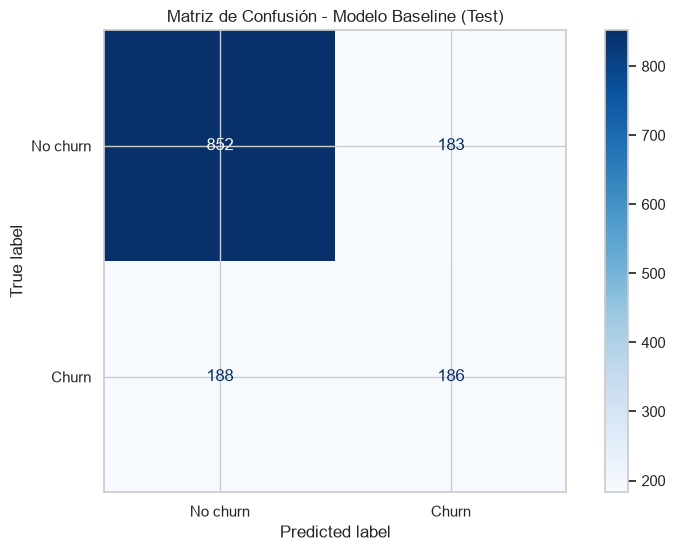


ROC-AUC: 0.6598


In [11]:
#Reporte completo (precision, recall, f1 por clase)
print("=== TEST ===")
print(classification_report(y_test, y_pred_test, target_names=["No churn", "Churn"]))


#Matriz de confunsión visual
cm= confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churn"])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Modelo Baseline (Test)')
plt.show()

# ROC-AUC (necesita las probabilidades, no solo la predicción de clase)
y_proba_test = modelo_baseline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba_test)
print(f"\nROC-AUC: {auc:.4f}")

Interpretación de los resultados:
1. Recall de "Churn" = 0.50 — este es el dato más importante del negocio: de cada 10 clientes que realmente se iban a ir, el modelo solo detectó 5 y se le escaparon 5.
2. Precision de "Churn" = 0.50 — de cada 10 clientes que el modelo marcó como "se va a ir", solo 5 realmente se iban. La otra mitad son falsas alarmas.
3. Precision de "Churn" = 0.50 — de cada 10 clientes que el modelo marcó como "se va a ir", solo 5 realmente se iban. La otra mitad son falsas alarmas.

Conclusión: El modelo memorizó ruido en el training set.

Por qué pasó esto? Con profundidad 24 y 1088 hojas, muchas de esas hojas terminaron con muy pocas observaciones (a veces 1 o 2 clientes). El árbol creó reglas ultra-específicas tipo "si MonthlyCharges es exactamente 73.45 Y tenure es exactamente 8 Y Contract=0 Y..." — reglas que describen perfectamente a un cliente puntual del training set, pero que no representan ningún patrón real y generalizable sobre el comportamiento de churn. 

## PASO 6: Poda del árbol (Regularización)

Los hiperparámetros clave de DecisionTreeClassifier para limitar que tan libre puede crecer el modelo son:
* max_depth: profundidad máxima permitida. Limita cuántas preguntas seguidas puede hacer el árbol antes de llegar a una hoja.
* min_samples_split: número mínimo de observaciones que debe tener un nodo para poder dividirse más. Si un nodo tiene pocas observaciones, no vale la pena seguir dividiéndolo (sería sobreajuste puro).
* min_samples_leaf: número mínimo de observaciones que debe tener cada hoja final. Esto directamente evita esas hojas ultra-específicas de 1-2 clientes que vimos arriba.
* ccp_alpha: parámetro de "poda por complejidad de costo" (cost-complexity pruning) — un enfoque más sofisticado que penaliza árboles complejos matemáticamente, en vez de solo limitar profundidad a mano.

6.1 — Primero, veamos visualmente el problema (opcional pero muy ilustrativo)

Antes de podar, vale la pena que veas al menos las primeras capas del árbol monstruoso que entrenamos, para que conectes la teoría con lo visual:

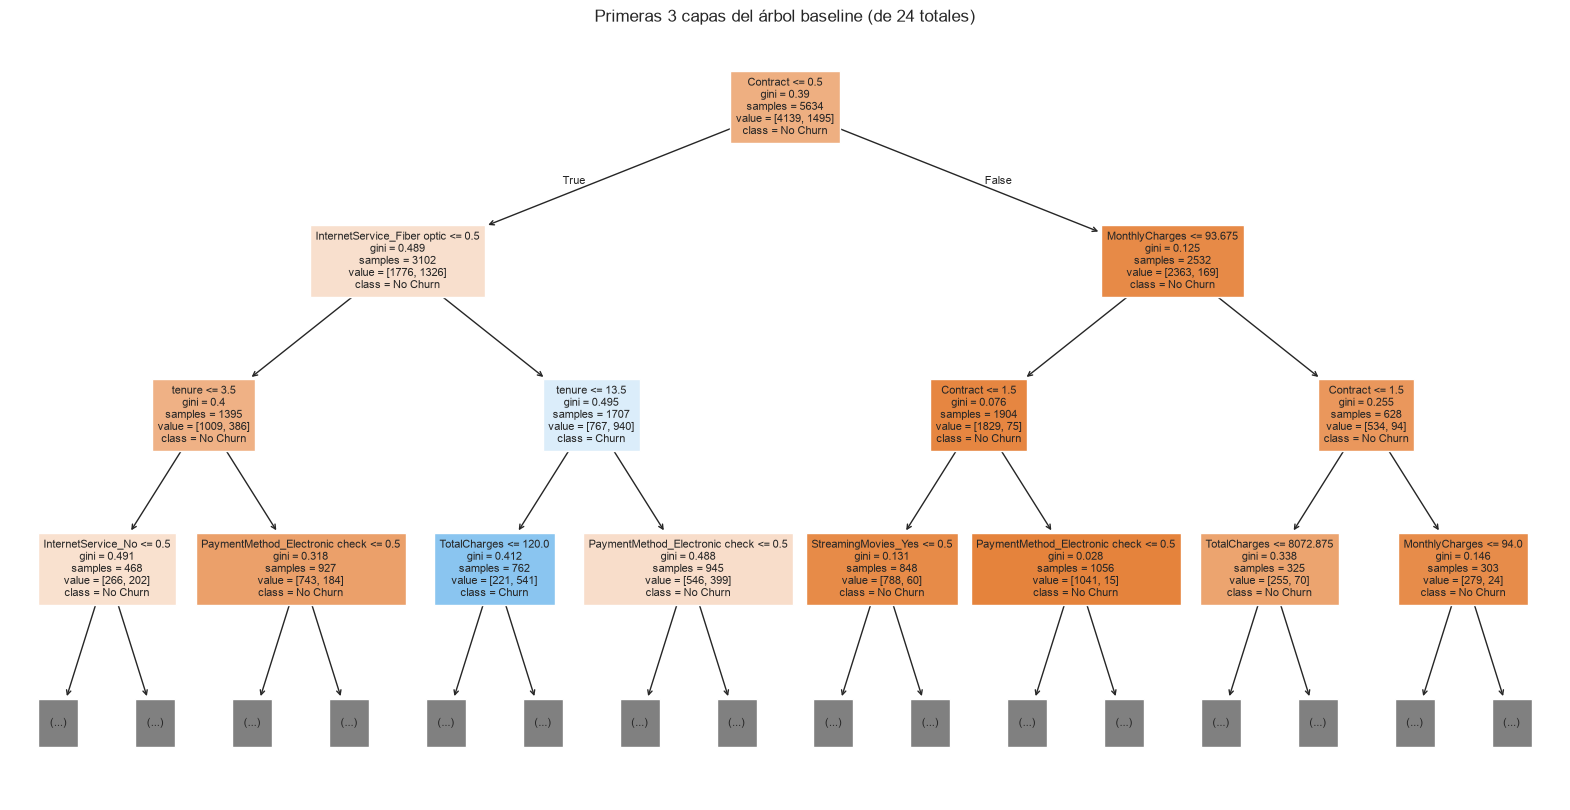

In [12]:

plt.figure(figsize=(20, 10))
plot_tree(modelo_baseline, max_depth=3, feature_names=X.columns, 
          class_names=['No Churn', 'Churn'], filled=True, fontsize=8)
plt.title('Primeras 3 capas del árbol baseline (de 24 totales)')
plt.show()

6.2 — Código: búsqueda de hiperparámetros con GridSearchCV y validación cruzada

In [13]:
#Definimos la "rejilla" de valores a probar sistemáticamente
param_grid = {
    'max_depth':[3,5,7,10,15],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

#GridSearchCV, prueba TODAS las combinaciones posibles usando 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='recall', #Es nuestra métrica principal a evaluar
    cv=5, #5-fold cross-validation
    n_jobs=-1  #Usa todos los núcleos del procesador para acelerar
)

grid_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor recall promedio (De cross-validation): {grid_search.best_score_:.4f}")


Mejores hiperparámetros: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 10}
Mejor recall promedio (De cross-validation): 0.5097


## CONCLUSION:
 Hemos obtneido un recall similar a cuando hicimos el modelo base line, por lo que el problema principal es el desbalanceo, así que debemos tratar con esto pero antes. **ME PARECIO QUE LO MEJOR ERA CORRER MLFLOW, PARA PONER EL PRACTICA Y COMO ESTABAMOS PROBANDO CON EXPERIEMNTOS, TENER EL TRACKEO**

Pasos siguientes a implementar: 
1. Ejecutar mlflow
2. volver con el modelo y hacer ajustes para mejorar el desbalanceo de las clases

In [14]:
# Le decimos a MLflow dónde guardar los experimentos (carpeta local por ahora)
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Creamos/seleccionamos el experimento
mlflow.set_experiment("telco_churn_decision_tree")

<Experiment: artifact_location='file:c:/Users/Usuario/telco-churn-mlops/notebooks/mlruns/1', creation_time=1784918794239, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784918794239, lifecycle_stage='active', name='telco_churn_decision_tree', tags={}, trace_location=None, workspace='default'>

7.4 — Logueando el modelo BASELINE (recuperamos ese experimento que ya corrimos) y lo guardamos en MLFLOW

In [16]:
with mlflow.start_run(run_name="baseline_sin_restricciones"):

    #Reentrenamos el baseline (mismo código de antes, ahora dentro del run)
    modelo_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
    modelo_baseline.fit(X_train,y_train)

    y_pred_test = modelo_baseline.predict(X_test)
    y_proba_test = modelo_baseline.predict_proba(X_test)[:, 1]

    #Calculamos las métricas
    acc = accuracy_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_proba_test)
    
    #Logueamos parámetros (info descriptiva del experimento)
    mlflow.log_param("max_depth", "None (sin límite)")
    mlflow.log_param("min_samples_splir", "default (2)")
    mlflow.log_param("min_samples_leaf", "default (1)")

    #Logueamos métricas (Los resultados numéricos)
    mlflow.log_metric("accuracy_test",acc)
    mlflow.log_metric("recall_test", recall)
    mlflow.log_metric("precision_test", precision)
    mlflow.log_metric("f1_test", f1)
    mlflow.log_metric("roc_auc_test", auc)

    #logueamos el modelo entrenado como artefacto
    mlflow.sklearn.log_model(modelo_baseline, "modelo")

    print(f"Baseline logueado - Recall: {recall:.4f}, Accuracy: {acc:.4f}")


2026/07/25 13:28:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Baseline logueado - Recall: 0.4973, Accuracy: 0.7367


In [20]:
with mlflow.start_run(run_name="podado_withgridsearch_recall"):

    mejor_modelo = grid_search.best_estimator_

    y_pred_test = mejor_modelo.predict(X_test)
    y_proba_test = mejor_modelo.predict_proba(X_test)[:, 1]

    #Calculamos las métricas
    acc = accuracy_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_proba_test)
    
    #Logueamos Hiper-parámetros reales encontrador por GridSearch
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("recall_cv_promedio", grid_search.best_score_)


    #Logueamos métricas (Los resultados numéricos)
    mlflow.log_metric("accuracy_test",acc)
    mlflow.log_metric("recall_test", recall)
    mlflow.log_metric("precision_test", precision)
    mlflow.log_metric("f1_test", f1)
    mlflow.log_metric("roc_auc_test", auc)

    #logueamos el modelo entrenado como artefacto
    mlflow.sklearn.log_model(modelo_baseline, "modelo")

    print(f"Podado logueado - Recall test: {recall:.4f}, Recall CV: {grid_search.best_score_:.4f}")

    


2026/07/25 13:31:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Podado logueado - Recall test: 0.5829, Recall CV: 0.5097


Conclusión: Implementamos un grid que buscara los mejores hiperparametros para el arbol de decision, pero aúnque mejoro los resultados, no se logro un alto desempeño por lo tanto vamos a implementar técnicas de desbalaneo 

# PASO 8 Atacar el desbalance de clases 
1. Lo hacemos con la class_weight = 'balanced'. Esto es porque es la más simple  (No modifica los datos, solamente el algoritmo penaliza los errores)
2. Usamos SMOTE 

8.1 - Repetimos el GridSearch, ahora con class_weight='balanced'

In [22]:
param_grid_balanced = {
    'max_depth': [3,5,7,10,15], #profundidad del árbol
    'min_samples_split': [10,20,50], #número mínimo de muestras/filas
    'min_samples_leaf': [5,10,20] #número mínimo de muestras que deben quedar en cada fila
}

grid_search_balanced = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid=param_grid_balanced,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_search_balanced.fit(X_train, y_train)

print(f"Mejor hiperparametros: {grid_search_balanced.best_params_}")
print(f"Mejor recall promedio (CV): {grid_search_balanced.best_score_:.4f}")

Mejor hiperparametros: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 10}
Mejor recall promedio (CV): 0.8054


8.2 - Logueamos este experimento en MLflow

In [24]:
with mlflow.start_run(run_name='podado_class_weight_balanced'):

    mejor_modelo_balanced = grid_search_balanced.best_estimator_

    y_pred_test = mejor_modelo_balanced.predict(X_test)
    y_proba_test = mejor_modelo_balanced.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    f1 =  f1_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_pred_test)

    mlflow.log_params(grid_search_balanced.best_params_)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("recall_cv_promedio", grid_search_balanced.best_score_)

    mlflow.log_metric("accuracy_test", acc)
    mlflow.log_metric("recall_test", recall)
    mlflow.log_metric("precision_test", precision)
    mlflow.log_metric("f1_test", f1)
    mlflow.log_metric("roc_auc_test", auc)

    mlflow.sklearn.log_model(mejor_modelo_balanced,"modelo")

    print(f"Class_weight logueado - Recall test: {recall:.4f}, Precision test: {precision:.4f}")

2026/07/26 11:25:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Class_weight logueado - Recall test: 0.7914, Precision test: 0.5276


# Paso 9: SMOTE (Synthetic Minority Oversampling Technique)

In [27]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Antes del SMOTE: ")
print(y_train.value_counts())
print("\nDespués del SMOTE: ")
print(y_train_smote.value_counts())


Antes del SMOTE: 
Churn
0    4139
1    1495
Name: count, dtype: int64

Después del SMOTE: 
Churn
0    4139
1    4139
Name: count, dtype: int64


Conlusión: Podemos ver que ahora ambas clases tienen exactamente el mismo número de observaciones en el training set (50/50). El test set (X_test, y_test) permanece intacto

GridSearch entrenado sobre los datos con SMOTE

In [32]:
param_grid_smote ={
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

grid_search_smote = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_smote,
    scoring='recall',
    cv=5,
    n_jobs=-1
)
grid_search_smote.fit(X_train_smote,y_train_smote)

print(f"Mejores hiperparametros: {grid_search_smote.best_params_}")
print(f"Mejor recall promedio (CV): {grid_search_smote.best_score_:.4f}")

Mejores hiperparametros: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 50}
Mejor recall promedio (CV): 0.8435


9.4 - Logueamos en MLflow  (evaluando siempre contra el test set ORIGINAL)

In [34]:
with mlflow.start_run(run_name="podado_smote"):

    mejor_modelo_smote = grid_search_smote.best_estimator_

    #Evaluamos y SIEMPRE contra X_test/y_test
    y_pred_test = mejor_modelo_smote.predict(X_test)
    y_proba_test = mejor_modelo_smote.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    f1 =  f1_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_pred_test)

    mlflow.log_params(grid_search_smote.best_params_)
    mlflow.log_param("class_weight", "SMOTE")
    mlflow.log_metric("recall_cv_promedio", grid_search_smote.best_score_)

    mlflow.log_metric("accuracy_test", acc)
    mlflow.log_metric("recall_test", recall)
    mlflow.log_metric("precision_test", precision)
    mlflow.log_metric("f1_test", f1)
    mlflow.log_metric("roc_auc_test", auc)

    mlflow.sklearn.log_model(mejor_modelo_smote,"modelo")

    print(f"SMOTE logueado - Recall test: {recall:.4f}, Precision test: {precision:.4f}")

2026/07/29 16:30:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


SMOTE logueado - Recall test: 0.6631, Precision test: 0.5368


## Comparación final y selección del modelo campeón

In [36]:
resultados = mlflow.search_runs(experiment_ids=[mlflow.get_experiment_by_name("telco_churn_decision_tree").experiment_id])


tabla_comparativa = resultados[['tags.mlflow.runName', 'metrics.recall_test', 
                                  'metrics.precision_test', 'metrics.f1_test', 
                                  'metrics.accuracy_test', 'metrics.roc_auc_test']]
tabla_comparativa.columns = ["Modelo", "Recall","Precision","F1", "Accutacy", "ROC-AUC"]
tabla_comparativa = tabla_comparativa.sort_values('Recall', ascending=False)
tabla_comparativa

,Modelo,Recall,Precision,F1,Accutacy,ROC-AUC
4,podado_class_weight_balanced,0.791444,0.527629,0.633155,0.756565,0.767703
0,podado_smote,0.663102,0.536797,0.593301,0.758694,0.728169
6,podado_withgridsearch_recall,0.582888,0.631884,0.606398,0.799148,0.831891
10,baseline_sin_restricciones,0.497326,0.504065,0.500673,0.736693,0.659772
11,baseline_sin_restricciones,0.497326,0.504065,0.500673,0.736693,0.659772
1,podado_smote,NaN,NaN,NaN,NaN,NaN
2,podado_smote,NaN,NaN,NaN,NaN,NaN
3,podado_smote,NaN,NaN,NaN,NaN,NaN
5,podado_class_weight_balanced,NaN,NaN,NaN,NaN,NaN
7,podado_withgridsearch_recall,NaN,NaN,NaN,NaN,NaN


A ganado el modelo con el metodo class_weight=balanced con sus hiperparametros

Guardamos el modelo campeon, (ya estaba guaradao, solo quye lo volvemos a guardar con nombre diferente para diferencias que es el campeon)

In [38]:
with mlflow.start_run(run_name="MODELO_FINAL_seleccionado"):
    
    # Reentrenamos con los mejores hiperparámetros encontrados en el experimento ganador
    modelo_final = grid_search_balanced.best_estimator_
    
    y_pred_test = modelo_final.predict(X_test)
    y_proba_test = modelo_final.predict_proba(X_test)[:, 1]
    
    mlflow.log_params(grid_search_balanced.best_params_)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("justificacion", "Prioriza recall para minimizar clientes perdidos sin detectar; mejor F1-score general")
    
    mlflow.log_metric("recall_test", recall_score(y_test, y_pred_test))
    mlflow.log_metric("precision_test", precision_score(y_test, y_pred_test))
    mlflow.log_metric("f1_test", f1_score(y_test, y_pred_test))
    mlflow.log_metric("roc_auc_test", roc_auc_score(y_test, y_proba_test))
    
    mlflow.sklearn.log_model(modelo_final, "modelo")
    mlflow.set_tag("estado", "campeon")
    
    run_id_final = mlflow.active_run().info.run_id
    print(f"Modelo final logueado. Run ID: {run_id_final}")

2026/07/29 17:19:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Modelo final logueado. Run ID: 46342c4bbe7744f4a4225d31ad19c933
